# Athlete Nutrition ML Notebook 



 1. INTRODUCTION

In this notebook, I build a machine learning pipeline to predict daily calorie needs for athletes based on features such as weight, height, age, sport type, intensity, and goal.

The workflow includes:

1. INTRODUCTION

2. Data loading

3. Data cleaning

4. Exploratory Data Analysis (EDA)

5. Data preprocessing

6. Train a neural network using PyTorch Lightning

7. Use early stopping to prevent overfitting


PyTorch Lightning is used to structure the training process in a clean and scalable way.

In [70]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
torch.manual_seed(42)

2. LOAD DATA

In this step, I load the dataset from an Excel file and inspect its structure to understand the available features and data types.

In [71]:
df = pd.read_excel("../dataset/athlete_nutrition_dataset.xlsx")
df.head()

,Sport,Weight,Height,Age,Goal,PreviousDay2_Intensity,PreviousDay2_Duration,PreviousDay1_Intensity,PreviousDay1_Duration,CurrentDay_Intensity,CurrentDay_Duration,Calories
0,bodybuilding,72,160,26,muscle_gain,high,33,medium,92,medium,100,3501
1,mma,84,160,20,fat_loss,low,111,low,97,medium,57,3040
2,bodybuilding,92,198,28,muscle_gain,high,94,low,70,high,49,3923
3,running,78,195,31,fat_loss,high,56,high,115,medium,100,3139
4,mma,77,171,39,endurance_performance,medium,67,medium,34,low,111,3451


In [72]:
# Dataset info
df.info()

# Shape of dataset
print("Dataset shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Sport                   1500 non-null   str  
 1   Weight                  1500 non-null   int64
 2   Height                  1500 non-null   int64
 3   Age                     1500 non-null   int64
 4   Goal                    1500 non-null   str  
 5   PreviousDay2_Intensity  1500 non-null   str  
 6   PreviousDay2_Duration   1500 non-null   int64
 7   PreviousDay1_Intensity  1500 non-null   str  
 8   PreviousDay1_Duration   1500 non-null   int64
 9   CurrentDay_Intensity    1500 non-null   str  
 10  CurrentDay_Duration     1500 non-null   int64
 11  Calories                1500 non-null   int64
dtypes: int64(7), str(5)
memory usage: 140.8 KB
Dataset shape: (1500, 12)


The dataset contains the following columns:

Sport

Weight

Height

Age

Goal

PreviousDay2_Intensity

PreviousDay2_Duration   

PreviousDay1_Intensity  

PreviousDay1_Duration  

CurrentDay_Intensity   

CurrentDay_Duration 

Calories (target variable)

3. DATA EXPLORATION (EDA)

3.1 DATA QUALITY CHECK

Here I check for missing values and duplicates.

In [73]:
# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

Missing values:
 Sport                     0
Weight                    0
Height                    0
Age                       0
Goal                      0
PreviousDay2_Intensity    0
PreviousDay2_Duration     0
PreviousDay1_Intensity    0
PreviousDay1_Duration     0
CurrentDay_Intensity      0
CurrentDay_Duration       0
Calories                  0
dtype: int64
Duplicates: 0


3.2 CLASS DISTRIBUTION (CATEGORICAL FEATURES)

Here I analyze how data is distributed across categories.

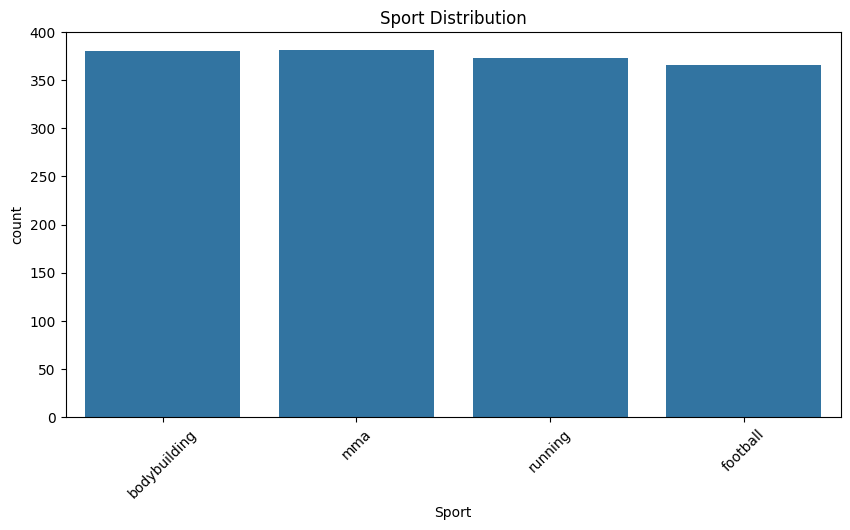

In [74]:
plt.figure(figsize=(10,5))
sns.countplot(x="Sport", data=df)
plt.title("Sport Distribution")
plt.xticks(rotation=45)
plt.show()

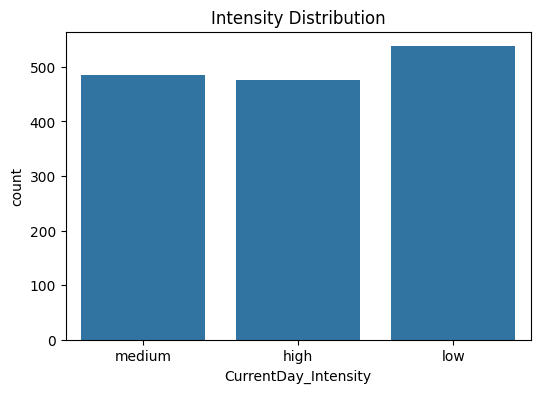

In [75]:
plt.figure(figsize=(6,4))
sns.countplot(x="CurrentDay_Intensity", data=df)
plt.title("Intensity Distribution")
plt.show()

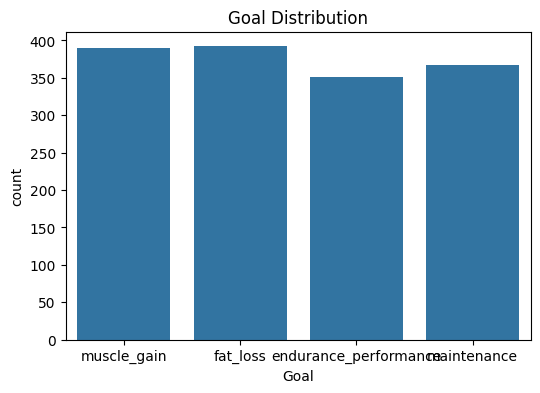

In [76]:
plt.figure(figsize=(6,4))
sns.countplot(x="Goal", data=df)
plt.title("Goal Distribution")
plt.show()

3.3 CORRELATION ANALYSIS

Here I check relationships between variables.

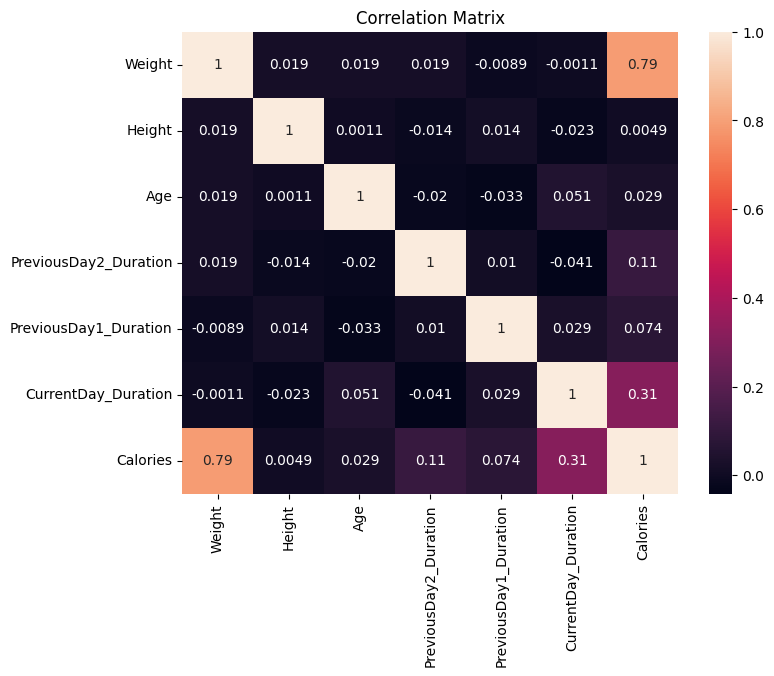

In [77]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

Weight likely has strong correlation with Calories

3.4 RELATIONSHIPS WITH TARGET (CALORIES)

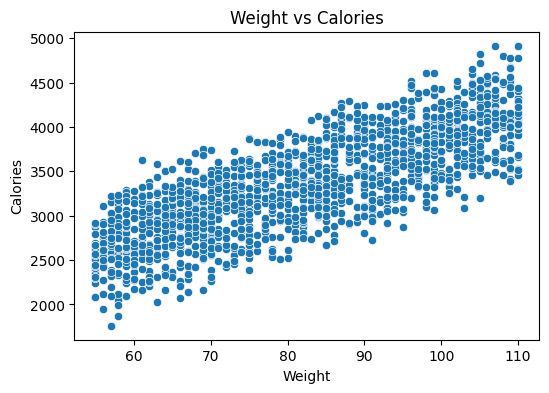

In [78]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Weight", y="Calories", data=df)
plt.title("Weight vs Calories")
plt.show()

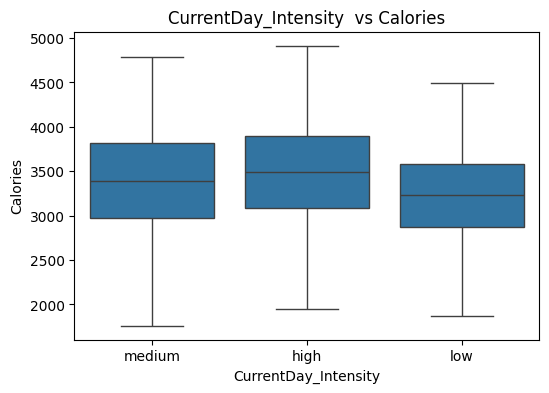

In [79]:
plt.figure(figsize=(6,4))
sns.boxplot(x="CurrentDay_Intensity", y="Calories", data=df)
plt.title("CurrentDay_Intensity  vs Calories")
plt.show()

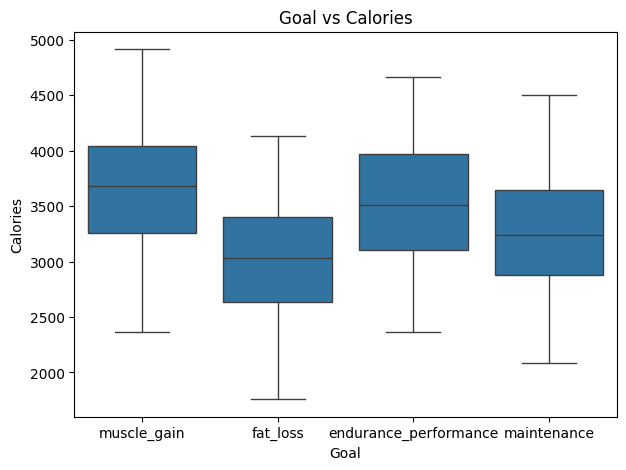

In [80]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Goal", y="Calories", data=df)
plt.title("Goal vs Calories")
plt.show()

4. PREPROCESSING

4.1 ENCODING CATEGORICAL VARIABLES

Machine learning models cannot understand text, so I convert categories into numbers.

In [81]:
df_encoded = pd.get_dummies(df, columns=["Sport", "CurrentDay_Intensity", "Goal"])

In [82]:
df_encoded = df_encoded.astype(np.float32)

ValueError: could not convert string to float: 'high'

Split features and target

In [ ]:
X = df_encoded.drop("Calories", axis=1).values
y = df_encoded["Calories"].values

4.2 FEATURE SCALING

Here I normalize numerical features.

In [ ]:
scaler = StandardScaler()
df[["Weight","Height","Age"]] = scaler.fit_transform(df[["Weight","Height","Age"]])

Normalization helps the model learn faster and improves performance.

4.3 Split Data (Train / Val / Test)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

5. SCALING (IMPORTANT FIX)

We scale AFTER splitting to avoid data leakage.

In [ ]:
scaler = StandardScaler()

X_train[:, :3] = scaler.fit_transform(X_train[:, :3])
X_val[:, :3] = scaler.transform(X_val[:, :3])
X_test[:, :3] = scaler.transform(X_test[:, :3])

6. PYTORCH DATASET

In [ ]:
class NutritionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
train_loader = DataLoader(NutritionDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(NutritionDataset(X_val, y_val), batch_size=32)
test_loader  = DataLoader(NutritionDataset(X_test, y_test), batch_size=32)

7. PYTORCH LIGHTNING MODEL 

In [ ]:
class NutritionModel(pl.LightningModule):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.network(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("val_loss", loss)

    def test_step(self, batch, batch_idx):  
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("test_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

8. EARLY STOPPING

Stops training when model stops improving.

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min"
)

9. TRAIN MODEL

In [ ]:
model = NutritionModel(input_size=X_train.shape[1])

trainer = pl.Trainer(
    max_epochs=50,
    callbacks=[early_stop]
)

trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name    | Type       | Params | Mode  | FLOPs
-------------------------------------------------------
0 | network | Sequential | 12.3 K | train | 0    
1 | loss_fn | MSELoss    | 0      | train | 0    
-------------------------------------------------------
12.3 K    Trainable params
0         Non-trainable params
12.3 K    Total params
0.049     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 27: 100%|██████████| 33/33 [00:00<00:00, 131.22it/s, v_num=1]         


10. LOSS VISUALIZATION

11. TEST EVALUATION

In [ ]:
trainer.test(model, test_loader)

Testing DataLoader 0: 100%|██████████| 8/8 [00:00<00:00, 279.62it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           1204.0015869140625
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 1204.0015869140625}]